In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from thermo import Chemical
from scipy.optimize import fsolve

################################################################# Fresh syngas ##########################################################################

T_fresh = 171.0 + 273.15 #K
P_fresh = 51e5 #Pa

F_fresh = 853.8 #kmol/h

y_fresh = [0.01630, 0.009370, 0.2167, 0.005354, 0.7523, 0]

################################################################### Recycle #############################################################################

P_recycle = 51e5 #Pa
F_recycle = 3822.0  # kmol/hr
T_recycle = 62.20 + 273.15  # K
y_recycle = [0.0689, 0.0213, 0.1188, 0.003, 0.7755, 0.0125]  # mole fraction

#################################################################### Mixer ##############################################################################

from thermo import (ChemicalConstantsPackage, PropertyCorrelationsPackage, CEOSGas, CEOSLiquid, FlashVL, PRMIX)
from thermo.interaction_parameters import IPDB

species = ['methane', 'carbon monoxide', 'carbon dioxide', 'water', 'hydrogen', 'methanol']

constants, correlations = ChemicalConstantsPackage.from_IDs(species)

kijs = IPDB.get_ip_asymmetric_matrix('ChemSep PR', constants.CASs, 'kij')

eos_kwargs = {'Tcs': constants.Tcs, 'Pcs': constants.Pcs, 'omegas': constants.omegas, 'kijs': kijs,}

gas = CEOSGas(PRMIX, eos_kwargs, HeatCapacityGases=correlations.HeatCapacityGases)
liquid = CEOSLiquid(PRMIX, eos_kwargs, HeatCapacityGases=correlations.HeatCapacityGases)

flasher = FlashVL(constants, correlations, gas=gas, liquid=liquid)

fresh = flasher.flash(T = T_fresh, P = P_fresh, zs = y_fresh)
recycle = flasher.flash(T = T_recycle, P = P_recycle, zs = y_recycle)

H_fresh = fresh.H() #J/mol
H_recycle = recycle.H() #J/mol

F_mix = F_fresh + F_recycle #kmol/h

y_mix = [max(1e-12, float((F_fresh * y_fresh[i] + F_recycle * y_recycle[i]) / F_mix)) for i in range(len(y_fresh))]
sum_y = sum(y_mix)
y_mix = [val / sum_y for val in y_mix]

H_mix = (F_fresh * H_fresh + F_recycle * H_recycle) / F_mix #J/mol

P_mix = min(P_fresh, P_recycle) #Pa

mix = flasher.flash(P = P_mix, H = H_mix, zs = y_mix)

T_mix = mix.T #K
density_mix = mix.rho_mass() #kg/m^3
moldensity_mix = mix.rho() #mol/m^3
visc_mix = mix.mu() #Pa.s
k_mix = mix.k() #W/mK
Cp_mix = mix.Cp_mass() #J/gK

################################################################## Preheater ############################################################################

T_ph_util_in = 260 + 273.15 #K
T_ph_util_out = 260 + 273.15 #K

T_ph = 250 + 273.15 #K
P_ph = P_mix - 0.3e5 #Pa

ph = flasher.flash(T = T_ph, P = P_ph, zs = y_mix)

H_ph = ph.H() #K
density_ph = ph.rho_mass() #kg/m^3
moldensity_ph = ph.rho() #mol/m^3
visc_ph = ph.mu() #Pa.s
k_ph = ph.k() #W/mK
Cp_ph = ph.Cp_mass() #J/gK

avg_density_ph = (density_mix + density_ph) / 2
avg_moldensity_ph = (moldensity_mix + moldensity_ph) / 2
avg_visc_ph = (visc_mix + visc_ph) / 2
avg_k_ph = (k_mix + k_ph) / 2
avg_Cp_ph = (Cp_mix + Cp_ph) / 2

def lmtd(delTh, delTc):
    return max((delTh - delTc) / np.log(delTh / delTc), 0)

LMTD_ph = lmtd(T_ph_util_in - T_ph, T_ph_util_out - T_mix)

Q_ph = abs(H_mix - H_ph) * F_mix / 3.6 #W

d_ph_ti = 0.020 #m
u_ph = 20 #m/s

h_ph_o = 5000 #W/m^2K

Re_ph = avg_density_ph * d_ph_ti * u_ph / avg_visc_ph
Pr_ph = avg_Cp_ph * avg_visc_ph / avg_k_ph
Nu_ph = 0.023 * (Re_ph ** 0.8) * (Pr_ph ** 0.4)

if Re_ph >= 1e4:
    regime_ph = 'Turbulent flow'

elif Re_ph <= 2300:
    regime_ph = 'Laminar flow'

else:
    regime_ph = 'Transitional flow'

h_ph_i = avg_k_ph * Nu_ph / d_ph_ti #W/m^2K

U_ph = 1/((1/h_ph_i) + (1/h_ph_o)) #W/m^2K

A_ph = Q_ph / (U_ph * LMTD_ph) #m^2

V_mix = F_mix / (3.6 * avg_moldensity_ph) #m^3/s

N_ph_t = V_mix / (u_ph * np.pi/4 * (d_ph_ti ** 2)) #tubes

L_ph_t = A_ph / (np.pi * d_ph_ti * N_ph_t) #m

f_ph_D = 0.3164 * (Re_ph ** -0.25)

P_ph_drop = f_ph_D * L_ph_t * avg_density_ph * (u_ph ** 2) / (d_ph_ti * 2) #Pa

T_rfeed = T_ph
P_rfeed = P_mix - P_ph_drop
y_rfeed = y_mix

# COSTING -- Floating head heat exchanger (Turton et al)

K1_ph = 4.8306
K2_ph = -0.8509
K3_ph = 0.3187

Cp0_ph = 10 ** (K1_ph + K2_ph * np.log10(A_ph) + K3_ph * (np.log10(A_ph)) ** 2)

C1_ph = 0.03881
C2_ph = -0.11272
C3_ph = 0.08183

Fp_ph = 10 ** (C1_ph + C2_ph * np.log10(P_mix * 1e-5 - 1) + C3_ph * (np.log10(P_mix * 1e-5 - 1)) ** 2)

Fm_ph = 1.8 # CS_shell - SS_tube

B1_ph = 1.63
B2_ph = 1.66

Cbm_ph = Cp0_ph * (B1_ph + B2_ph * Fm_ph * Fp_ph)

CEPCI_2001 = 397
CEPCI_2026 = 800 #Estimated

Cost_ph = Cbm_ph * CEPCI_2026 / CEPCI_2001 * 16.42

hps_cost = 17.7 * 16.42 #ZAR per GJ
cw_cost = 0.354 * 16.42 #ZAR per GJ
bfw_cost = 2.45 / (2200 * 1000) * 1e6 * 16.42 #ZAR per GJ
elec_cost = 3.2 #ZAR per kWh

op_ph = hps_cost * Q_ph * 3600 / 1e9 #ZAR per hour

################################################################### Reactor #############################################################################

y0 = [float(x * F_mix / 3.6) for x in y_rfeed] + [float(T_rfeed), float(P_rfeed)]

# Mole balance

wall_thickness = 0.002 #m

d_ti = 0.058 #m
d_to = d_ti + 2 * wall_thickness #m

d_p = 0.00542 #m
L_p = 0.0052 #m
L_char = d_p * L_p / (2 * d_p + 4 * L_p)

N_t = 2500 #tubes
A_r_c = (np.pi / 4) * (d_ti ** 2) #m^2

A1, A2, A3, A4, A5 = 0.499, 6.62e-11, 3453.38, 1.07, 1.22e10
B1, B2, B3, B4, B5 = 17197, 124119, 0, 36696, -94765

R = 8.3145 #J/molK

# Energy balance

R_fi = 0.00015 #m^2K/W
R_fo = 0.00015 #m^2K/W

k_wall = 40 #W/mK

a_L = np.pi * d_to #m^2/m

delHrxn1_298 = -49.7e3 #J/mol
delHrxn2_298 = 41.5e3 #J/mol

co = Chemical('Carbon monoxide', T=T_rfeed, P=P_rfeed)
co2 = Chemical('Carbon dioxide', T=T_rfeed, P=P_rfeed)
h2o = Chemical('Water', T=T_rfeed, P=P_rfeed)
h2 = Chemical('Hydrogen', T=T_rfeed, P=P_rfeed)
ch3oh = Chemical('Methanol', T=T_rfeed, P=P_rfeed)

Cp_B = co.Cpgm #J/molK
Cp_C = co2.Cpgm #J/molK
Cp_D = h2o.Cpgm #J/molK
Cp_E = h2.Cpgm #J/molK
Cp_F = ch3oh.Cpgm #J/molK

delCprxn1 = Cp_F + Cp_D - Cp_C - 3 * Cp_E #J/molK
delCprxn2 = Cp_B + Cp_D - Cp_C - Cp_E #J/molK

delHrxn1 = delHrxn1_298 + delCprxn1 * (T_rfeed - 298.15) #J/mol
delHrxn2 = delHrxn2_298 + delCprxn2 * (T_rfeed - 298.15) #J/mol

Temp_util_in = 240 + 273.15 #K

util_sat = Chemical('Water', T=Temp_util_in)
Press_util_in = util_sat.Psat
util = Chemical('Water', T=Temp_util_in, P=Press_util_in)

Cp_util_liq = util.Cpl #J/kgK
rho_util_liq = util.rhol #kg/m^3
mu_util_liq = util.mul #Pa.s
k_util_liq = util.kl #W/m/K

rho_util_vap = util.rhog #kg/m^3
mu_util_vap = util.mug #Pa.s
k_util_vap = util.kg #W/m/K

Hvap_util = util.Hvap #J/kg
sigma_util = util.sigma #N/m

Pr_util_liq = Cp_util_liq * mu_util_liq / k_util_liq

g = 9.807 #m/s^2
C_sf = 0.013 #constant
n_rohsenow = 1.0

# Momentum balance

void = 0.39
tort = 3
particle_density = 1770 #kg/m^3
d_pore = 15e-9 #m
bed_density = particle_density * (1 - void) #kg/m^3

def reactor(L, y):
    FA, FB, FC, FD, FE, FF, T, P = y

    F_tot = FA + FB + FC + FD + FE + FF #mol/s

    yA = FA / F_tot
    yB = FB / F_tot
    yC = FC / F_tot
    yD = FD / F_tot
    yE = FE / F_tot
    yF = FF / F_tot

    y_L = [yA, yB, yC, yD, yE, yF]

    mix_rx = flasher.flash(T = T, P = P, zs = y_L)
    mix_moldensity = mix_rx.rho() #mol/m^3
    mix_density = mix_rx.rho_mass() #kg/m^3
    mix_visc = mix_rx.mu() #Pa.s
    mix_k = mix_rx.k() #W/mK
    mix_molCp = mix_rx.Cp() #J/molK
    
    # Mole balance
    
    pA = FA * P / (F_tot * 1e5) # bar
    pB = FB * P / (F_tot * 1e5) # bar
    pC = FC * P / (F_tot * 1e5) # bar
    pD = FD * P / (F_tot * 1e5) # bar
    pE = FE * P / (F_tot * 1e5) # bar
    pF = FF * P / (F_tot * 1e5) # bar
    
    K1 = 10 ** (3066 / T - 10.592)
    K3 = 1 / (10 ** (-2073 / T + 2.029))
    
    X1 = A1 * np.exp(B1 / (R * T))
    X2 = A2 * np.exp(B2 / (R * T))
    X3 = A3 * np.exp(B3 / (R * T))
    X4 = A4 * np.exp(B4 / (R * T))
    X5 = A5 * np.exp(B5 / (R * T))

    r1_int = ((X4 * pC * pE * (1 - (1 / K1) * (pD * pF / ((pE ** 3) * pC)))) / ((1 + X3 * (pD / pE) + X1 * (pE ** 0.5) + X2 * pD) ** 3)) #mol/kgcats
    r2_int = (X5 * pC * (1 - K3 * (pD * pB / (pC * pE))) / (1 + X3 * (pD / pE) + X1 * (pE ** 0.5) + X2 * pD)) #mol/kgcats

    Q = F_tot / mix_moldensity #m^3/s
    u_sf = Q / (N_t * A_r_c) #m/s

    Re_p = mix_density * d_p * u_sf / mix_visc

    y_r = np.maximum(y_L, 1e-12)
    CC = FC / Q #mol/m^3

    D_CA = 1.013e-2 * T ** 1.75 * (1 / 44 + 1 / 16) ** 0.5 / (P * (26.9 ** (1 / 3) + 24.42 ** (1 / 3)) ** 2)
    D_CB = 1.013e-2 * T ** 1.75 * (1 / 44 + 1 / 28) ** 0.5 / (P * (26.9 ** (1 / 3) + 18.9 ** (1 / 3)) ** 2)
    D_CD = 1.013e-2 * T ** 1.75 * (1 / 44 + 1 / 18) ** 0.5 / (P * (26.9 ** (1 / 3) + 12.7 ** (1 / 3)) ** 2)
    D_CE = 1.013e-2 * T ** 1.75 * (1 / 44 + 1 / 2) ** 0.5 / (P * (26.9 ** (1 / 3) + 7.07 ** (1 / 3)) ** 2)
    D_CF = 1.013e-2 * T ** 1.75 * (1 / 44 + 1 / 32) ** 0.5 / (P * (26.9 ** (1 / 3) + 29.9 ** (1 / 3)) ** 2)

    D_Cm = (1 - y_r[2]) / (y_r[0] / D_CA + y_r[1] / D_CB + y_r[3] / D_CD + y_r[4] / D_CE + y_r[5] / D_CF)

    D_CK = (d_pore / 3) * (8 * R * T / (np.pi * 44e-3)) ** 0.5
    D_Cp = 1 / (1 / D_CK + 1 / D_Cm)
    D_Ceff = void * D_Cp / tort

    thiele_1 = L_char * (np.abs(r1_int) * particle_density / (D_Ceff * CC)) ** 0.5
    thiele_2 = L_char * (np.abs(r2_int) * particle_density / (D_Ceff * CC)) ** 0.5

    eta_1 = 3 / thiele_1 * (1 / np.tanh(thiele_1) - 1 / thiele_1) if thiele_1 > 1e-6 else 1.0  # dimensionless
    eta_2 = 3 / thiele_2 * (1 / np.tanh(thiele_2) - 1 / thiele_2) if thiele_2 > 1e-6 else 1.0  # dimensionless
    
    r1 = eta_1 * r1_int
    r2 = eta_2 * r2_int

    dFAdL = N_t * bed_density * A_r_c * (0)
    dFBdL = N_t * bed_density * A_r_c * (r2)
    dFCdL = -N_t * bed_density * A_r_c * (r1 + r2)
    dFDdL = N_t * bed_density * A_r_c * (r1 + r2)
    dFEdL = -N_t * bed_density * A_r_c * (3 * r1 + r2)
    dFFdL = N_t * bed_density * A_r_c * (r1)

    # Energy balance

    Nu = 3.5 * (Re_p ** 0.7) * np.exp(-4.6 * (d_p / d_ti))
    h_i = mix_k * Nu/ d_ti

    q_flux = mu_util_liq * Hvap_util * (g * (rho_util_liq - rho_util_vap) / sigma_util) ** 0.5 * (Cp_util_liq * (T - Temp_util_in) / (C_sf * Hvap_util * Pr_util_liq ** n_rohsenow)) ** 3
    h_o = q_flux / (T - Temp_util_in)
    
    U_L = 1 / ((d_to / (d_ti * h_i)) + (d_to * R_fi / d_ti) + (d_to * np.log(d_to / d_ti) / (2 * k_wall)) + R_fo + 1 / h_o)
    
    H_rxn = r1 * delHrxn1 + r2 * delHrxn2

    H_flow = F_tot * mix_molCp
    
    dTdL = N_t * (U_L * a_L * (Temp_util_in - T) - bed_density * A_r_c * H_rxn) / (H_flow)

    # Momentum balance

    dPdL = -150 * ((1 - void) ** 2) * mix_visc * u_sf / ((void ** 3) * (d_p ** 2)) - 1.75 * (1 - void) * mix_density * (u_sf ** 2) / ((void ** 3) * (d_p))

    return dFAdL, dFBdL, dFCdL, dFDdL, dFEdL, dFFdL, dTdL, dPdL

L_t = 4 #m
L_t_span = np.linspace(0, L_t, 500)
L_t_vec = (0, L_t)

soln = solve_ivp(reactor, L_t_vec, y0, method = 'LSODA', dense_output = True, rtol = 1e-5, atol = 1e-7)

FA_r, FB_r, FC_r, FD_r, FE_r, FF_r, T_r, P_r = soln.sol(L_t_span)
F_mix_r = FA_r + FB_r + FC_r + FD_r + FE_r + FF_r #mol/s
T_r_out = T_r[-1]
P_r_out = P_r[-1]
y_r_out = [FA_r[-1]/F_mix_r[-1], FB_r[-1]/F_mix_r[-1], FC_r[-1]/F_mix_r[-1], FD_r[-1]/F_mix_r[-1], FE_r[-1]/F_mix_r[-1], FF_r[-1]/F_mix_r[-1]]

r = flasher.flash(T = T_r_out, P = P_r_out, zs = y_r_out)

H_r_out = r.H()
density_r_out = r.rho_mass()
moldensity_r_out = r.rho()
visc_r_out = r.mu()
k_r_out = r.k()
Cp_r_out = r.Cp_mass()

Q_reactor = (H_ph * (F_mix / 3.6) - H_r_out * F_mix_r[-1])
T_hotspot = np.max(T_r) - 273.15
L_hotspot = L_t_span[np.argmax(T_r)]

avg_density_r = (density_ph + density_r_out) / 2
avg_moldensity_r = (moldensity_ph + moldensity_r_out) / 2
avg_visc_r = (visc_ph + visc_r_out) / 2
avg_k_r = (k_ph + k_r_out) / 2
avg_Cp_r = (Cp_ph + Cp_r_out) / 2

Q_r = F_mix_r / avg_moldensity_r
u_sf_r = Q_r/((np.pi/4) * (d_ti**2) * N_t)

# Peclet number

Pe_r = 2 * L_t / d_p

if Pe_r > 1000:
    Pe_regime = '1D plug flow'

else:
    Pe_regime = '2D radial and axial flow'

# Thiele modulus

pA = FA_r * P_r / (F_mix_r * 1e5)
pB = FB_r * P_r / (F_mix_r * 1e5)
pC = FC_r * P_r / (F_mix_r * 1e5)
pD = FD_r * P_r / (F_mix_r * 1e5)
pE = FE_r * P_r / (F_mix_r * 1e5)
pF = FF_r * P_r / (F_mix_r * 1e5)

K1 = 10 ** (3066 / T_r - 10.592)
K3 = 1 / (10 ** (-2073 / T_r + 2.029))
    
X1 = A1 * np.exp(B1 / (R * T_r))
X2 = A2 * np.exp(B2 / (R * T_r))
X3 = A3 * np.exp(B3 / (R * T_r))
X4 = A4 * np.exp(B4 / (R * T_r))
X5 = A5 * np.exp(B5 / (R * T_r))
    
r1_int = ((X4 * pC * pE * (1 - (1 / K1) * (pD * pF / ((pE ** 3) * pC)))) / ((1 + X3 * (pD / pE) + X1 * (pE ** 0.5) + X2 * pD) ** 3))
r2_int = (X5 * pC * (1 - K3 * (pD * pB / (pC * pE))) / (1 + X3 * (pD / pE) + X1 * (pE ** 0.5) + X2 * pD))

y_r_prof = [FA_r/F_mix_r, FB_r/F_mix_r, FC_r/F_mix_r, FD_r/F_mix_r, FE_r/F_mix_r, FF_r/F_mix_r]
y_r_prof = np.maximum(y_r_prof, 1e-12)
CC = FC_r / (F_mix_r / avg_moldensity_r)

D_CA = 1.013e-2 * T_r ** 1.75 * (1 / 44 + 1 / 16) ** 0.5 / (P_r * (26.9 ** (1 / 3) + 24.42 ** (1 / 3)) ** 2)
D_CB = 1.013e-2 * T_r ** 1.75 * (1 / 44 + 1 / 28) ** 0.5 / (P_r * (26.9 ** (1 / 3) + 18.9 ** (1 / 3)) ** 2)
D_CD = 1.013e-2 * T_r ** 1.75 * (1 / 44 + 1 / 18) ** 0.5 / (P_r * (26.9 ** (1 / 3) + 12.7 ** (1 / 3)) ** 2)
D_CE = 1.013e-2 * T_r ** 1.75 * (1 / 44 + 1 / 2) ** 0.5 / (P_r * (26.9 ** (1 / 3) + 7.07 ** (1 / 3)) ** 2)
D_CF = 1.013e-2 * T_r ** 1.75 * (1 / 44 + 1 / 32) ** 0.5 / (P_r * (26.9 ** (1 / 3) + 29.9 ** (1 / 3)) ** 2)

D_Cm = (1 - y_r_prof[2]) / (y_r_prof[0] / D_CA + y_r_prof[1] / D_CB + y_r_prof[3] / D_CD + y_r_prof[4] / D_CE + y_r_prof[5] / D_CF)

D_CK = (d_pore / 3) * (8 * R * T_r / (np.pi * 44e-3)) ** 0.5
D_Cp = 1 / (1 / D_CK + 1 / D_Cm)
D_Ceff = void * D_Cp / tort

thiele_1 = L_char * (np.abs(r1_int) * particle_density / (D_Ceff * CC)) ** 0.5
thiele_2 = L_char * (np.abs(r2_int) * particle_density / (D_Ceff * CC)) ** 0.5

eta_1 = np.where(thiele_1 > 1e-6, 3 / thiele_1 * (1 / np.tanh(thiele_1) - 1 / thiele_1), 1.0)
eta_2 = np.where(thiele_2 > 1e-6, 3 / thiele_2 * (1 / np.tanh(thiele_2) - 1 / thiele_2), 1.0)

r1 = eta_1 * r1_int
r2 = eta_2 * r2_int

# Mears mass transfer criterion + Reynolds

Re_p_r = avg_density_r * d_p * u_sf_r / avg_visc_r
Sc_r = avg_visc_r / (avg_density_r * D_Cm)
Sh_r = 2 + 1.1 * Re_p_r ** 0.6 * Sc_r ** (1 / 3)
kc_r = Sh_r * D_Cm / d_p
CM_r = abs(r1 + r2) * particle_density * d_p / 2 * 1 / (kc_r * CC)

# Mears radial heat transfer criterion

r_vol = (r1 + r2) * bed_density
Pr_r = avg_Cp_r * avg_visc_r / avg_k_r
lambda_er = avg_k_r * (5.0 + 0.1 * Re_p_r * Pr_r)
E_a = abs(B4)
M_T = (abs(delHrxn1) * abs(r_vol) * d_ti**2 / (lambda_er * T_r) * E_a / (R * T_r))

idx = [int(f * (len(L_t_span) - 1)) for f in (0.25, 0.50, 0.75, 1.0)]

mears_rad = []
mears_ext = []
reynolds = []

for i in idx:

    mears_rad.append(M_T[i])

    mears_ext.append(CM_r[i])

    reynolds.append(Re_p_r[i])

mears_radial_ok = max(mears_rad) < 1.6
mears_ext_ok = max(mears_ext) < 0.15
reynolds_min_ok = min(reynolds) > 250
reynolds_max_ok = max(reynolds) < 3000

# COSTING -- Fixed tubesheet heat exchanger (Turton et al)

A_r_total = np.pi * d_to * L_t * N_t

max_area_per_shell = 1000.0
n_shells = np.ceil(A_r_total / max_area_per_shell)
A_per_shell = A_r_total / n_shells

K1_r = 4.3247
K2_r = -0.3030
K3_r = 0.1634

Cp0_r = 10 ** (K1_r + K2_r * np.log10(A_per_shell) + K3_r * (np.log10(A_per_shell)) ** 2)

C1_r = 0.03881
C2_r = -0.11272
C3_r = 0.08183

Fp_r = 10 ** (C1_r + C2_r * np.log10(P_rfeed * 1e-5 - 1) + C3_r * (np.log10(P_rfeed * 1e-5 - 1)) ** 2)

Fm_r = 1.8 # CS_shell - SS_tube

B1_r = 1.63
B2_r = 1.66

Cbm_r = Cp0_r * (B1_r + B2_r * Fm_r * Fp_r)

Cost_r = Cbm_r * n_shells * CEPCI_2026 / CEPCI_2001 * 16.42

C_cat = 30 #$ per kg

W_cat = N_t * A_r_c * L_t * bed_density

cat_life = 5 #years

Cost_cat = C_cat * W_cat / cat_life * 16.42

op_r = -(hps_cost - bfw_cost) * Q_reactor * 3600 / 1e9

################################################################## Cooler ###############################################################################

T_c_util_in = 30 + 273.15
T_c_util_out = 45 + 273.15

T_c = 60 + 273.15
P_c = P_r_out - 0.3e5

c = flasher.flash(T = T_c, P = P_c, zs = y_r_out)

H_c = c.H()
density_c = c.rho_mass()
moldensity_c = c.rho()
visc_c = c.mu()
k_c = c.k()
Cp_c = c.Cp_mass()

avg_density_c = (density_r_out + density_c) / 2
avg_moldensity_c = (moldensity_r_out + moldensity_c) / 2
avg_visc_c = (visc_r_out + visc_c) / 2
avg_k_c = (k_r_out + k_c) / 2
avg_Cp_c = (Cp_r_out + Cp_c) / 2

LMTD_c = lmtd(T_r_out - T_c_util_out, T_c - T_c_util_in)

Q_c = abs(H_r_out - H_c) * F_mix_r[-1]

d_c_ti = 0.020
u_c = 20

h_c_o = 500

Re_c = avg_density_c * d_c_ti * u_c / avg_visc_c
Pr_c = avg_Cp_c * avg_visc_c / avg_k_c
Nu_c = 0.023 * (Re_c ** 0.8) * (Pr_c ** 0.3)

if Re_c >= 1e4:
    regime_c = 'Turbulent flow'

elif Re_c <= 2300:
    regime_c = 'Laminar flow'

else:
    regime_c = 'Transitional flow'

h_c_i = avg_k_c * Nu_c / d_c_ti

U_c = 1/((1/h_c_i) + (1/h_c_o))

A_c = Q_c / (U_c * LMTD_c)

V_r_out = F_mix_r[-1] / (avg_moldensity_c)

N_c_t = V_r_out / (u_c * np.pi/4 * (d_c_ti ** 2))

L_c_t = A_c / (np.pi * d_c_ti * N_c_t)

f_c_D = 0.3164 * (Re_c ** -0.25)

P_c_drop = f_c_D * L_c_t * avg_density_c * (u_c ** 2) / (d_c_ti * 2)

# COSTING -- Floating head heat exchanger (Turton et al)

K1_c = 4.8306
K2_c = -0.8509
K3_c = 0.3187

Cp0_c = 10 ** (K1_c + K2_c * np.log10(A_c) + K3_c * (np.log10(A_c)) ** 2)

C1_c = 0.03881
C2_c = -0.11272
C3_c = 0.08183

Fp_c = 10 ** (C1_c + C2_c * np.log10(P_r_out * 1e-5 - 1) + C3_c * (np.log10(P_r_out * 1e-5 - 1)) ** 2)

Fm_c = 1.8 # CS_shell - SS_tube

B1_c = 1.63
B2_c = 1.66

Cbm_c = Cp0_c * (B1_c + B2_c * Fm_c * Fp_c)

Cost_c = Cbm_c * CEPCI_2026 / CEPCI_2001 * 16.42

op_c = cw_cost * Q_c * 3600 / 1e9

################################################################# Flash drum ############################################################################

F_flash = F_mix_r[-1]
T_flash = T_c
P_flash = max(1e5, P_r_out - P_c_drop)
y_flash = y_r_out

flash = flasher.flash(T = T_flash, P = P_flash, zs = y_flash)

VF_flash = flash.VF

F_liq = F_flash * (1 - VF_flash)
y_liq = flash.liquid0.zs

F_vap = F_flash * VF_flash
y_vap = flash.gas.zs

# COSTING -- Vertical process vessel (Turton et al)

moldensity_liq = flash.liquid0.rho()
density_liq = flash.liquid0.rho_mass()

moldensity_vap = flash.gas.rho()
density_vap = flash.gas.rho_mass()

Ks_fd = 0.107 #m/s

nu_max_fd = Ks_fd * ((density_liq - density_vap) / density_vap) ** 0.5
nu_op_fd = 0.9 * nu_max_fd

A_fd = F_vap / (moldensity_vap * nu_op_fd)
D_fd = (4 * A_fd / np.pi) ** 0.5
h_l_fd = 4 * F_liq / moldensity_liq * 5 * 60 / (np.pi * D_fd ** 2)
h_v_fd = max(1, D_fd)
h_fd = h_l_fd + h_v_fd
V_fd = np.pi * D_fd ** 2 / 4 * h_fd

K1_fd = 3.4974
K2_fd = 0.4485
K3_fd = 0.1074

Cp0_fd = 10 ** (K1_fd + K2_fd * np.log10(V_fd) + K3_fd * (np.log10(V_fd)) ** 2)

P_fd = P_flash * 1e-5 - 1

Fp_fd = max((((D_fd * (P_fd + 1)) / (2 * (850 - 0.6 * (P_fd + 1)))) + 0.00315) / 0.0063, 1)

Fm_fd = 3.1

B1_fd = 2.25
B2_fd = 1.82

Cbm_fd = Cp0_fd * (B1_fd + B2_fd * Fm_fd * Fp_fd)

Cost_fd = Cbm_fd * CEPCI_2026 / CEPCI_2001 * 16.42

################################################################### Splitter ############################################################################

split = 0.95

T_1 = T_flash
P_1 = P_flash

T_2 = T_flash
P_2 = P_flash

F_1 = split * F_vap
F_2 = (1 - split) * F_vap

y_1 = y_vap
y_2 = y_vap

################################################################## Compressor ###########################################################################

P_recycle = P_fresh

rec = flasher.flash(T = T_1, P = P_1, zs = y_1)

S_rec = rec.S()
H_rec = rec.H()

recy = flasher.flash(P = P_recycle, S = S_rec, zs = y_1)

isen_efficiency = 0.8

H_recycle = recy.H()

H_recycle_actual = H_rec + (H_recycle - H_rec) / isen_efficiency

W_co = F_1 * (H_recycle_actual - H_rec)

recycle = flasher.flash(P = P_recycle, H = H_recycle_actual, zs = y_1)

T_recycle1 = recycle.T
F_recycle1 = F_1 * 3.6
y_recycle1 = y_1

# COSTING

W_fluid = W_co * isen_efficiency

Wf_co = max(W_fluid/1e3, 450)

K1_co = 2.2897
K2_co = 1.3604
K3_co = -0.1027

Cp0_co_base = 10 ** (K1_co + K2_co * np.log10(Wf_co) + K3_co * (np.log10(Wf_co)) ** 2)

Cp0_co = Cp0_co_base * (W_fluid/(1e3 * 450)) ** 0.6

Fbm_co = 5.7

Cbm_co = Cp0_co * Fbm_co

Cost_co = Cbm_co * CEPCI_2026 / CEPCI_2001 * 16.42

op_co = elec_cost * W_co / 1e3

############################################################## Throttling valve #########################################################################

liq = flasher.flash(T = T_flash, P = P_flash, zs = y_liq)

H_liq = liq.H()

P_valve = 5e5
H_valve = H_liq

valve = flasher.flash(P = P_valve, H = H_valve, zs = y_liq)

T_valve = valve.T
F_valve = F_liq

############################################################# Distillation column #######################################################################

F_meoh = F_valve * y_liq[5]
F_h2o = F_valve * y_liq[3]

Feed = F_meoh + F_h2o

z_meoh = F_meoh / Feed
z_h2o = F_h2o / Feed

def nrtl(T_guess, P, x_1, params, ant1, ant2):

    R = 8.3145

    A_12, A_21, alpha_12 = params

    A1, B1, C1 = ant1
    A2, B2, C2 = ant2

    def solve(T):

        T = float(T[0])
    
        tau_12 = A_12 / (R * T)
        tau_21 = A_21 / (R * T)

        G_12 = np.exp(-alpha_12 * tau_12)
        G_21 = np.exp(-alpha_12 * tau_21)

        gamma_1 = np.exp(((1 - x_1) ** 2) * (tau_21 * (G_21 / (x_1 + (1 - x_1) * G_21)) ** 2 + tau_12 * G_12 / (((1 - x_1) + x_1 * G_12) ** 2)))
        gamma_2 = np.exp((x_1 ** 2) * (tau_12 * (G_12 / ((1 - x_1) + x_1 * G_12)) ** 2 + tau_21 * G_21 / ((x_1 + (1 - x_1) * G_21) ** 2)))

        Psat_1 = 10 ** (A1 - (B1 / (T + C1))) * 1e5
        Psat_2 = 10 ** (A2 - (B2 / (T + C2))) * 1e5

        eqn = -P + x_1 * gamma_1 * Psat_1 + (1 - x_1) * gamma_2 * Psat_2

        return eqn

    guess = [T_guess]

    T_ans = fsolve(solve, guess)

    T = T_ans[0]
    
    tau_12 = A_12 / (R * T)
    tau_21 = A_21 / (R * T)

    G_12 = np.exp(-alpha_12 * tau_12)
    G_21 = np.exp(-alpha_12 * tau_21)

    gamma_1 = np.exp(((1 - x_1) ** 2) * (tau_21 * (G_21 / (x_1 + (1 - x_1) * G_21)) ** 2 + tau_12 * G_12 / (((1 - x_1) + x_1 * G_12) ** 2)))
    gamma_2 = np.exp((x_1 ** 2) * (tau_12 * (G_12 / ((1 - x_1) + x_1 * G_12)) ** 2 + tau_21 * G_21 / ((x_1 + (1 - x_1) * G_21) ** 2)))

    Psat_1 = 10 ** (A1 - (B1 / (T + C1))) * 1e5
    Psat_2 = 10 ** (A2 - (B2 / (T + C2))) * 1e5

    K_1 = gamma_1 * Psat_1 / P
    K_2 = gamma_2 * Psat_2 / P

    alpha = K_1 / K_2

    y_1 = K_1 * x_1 / (K_1 * x_1 + K_2 * (1 - x_1))
    y_2 = 1 - y_1

    return T, y_1, y_2, alpha

params = [-189.0469, 792.8020, 0.2999] #MeOH - Water interaction parameters
ant1 = [5.15853, 1569.613, -34.846] #Antoine coefficients for MeOH (T in K, P in bar)
ant2 = [3.55959, 643.748, -198.043] #Antoine coefficients for H2O (T in K, P in bar)

x_meoh_D = 0.991
x_h2o_B = 0.999

T_bubble_feed = nrtl(110 + 273.15, 5e5, z_meoh, params, ant1, ant2)[0]

top = nrtl(110 + 273.15, 5e5, x_meoh_D, params, ant1, ant2)
bot = nrtl(150 + 273.15, 5e5, (1 - x_h2o_B), params, ant1, ant2)

r_vol_top = top[3]
r_vol_bot = bot[3]

r_vol_avg = (r_vol_top * r_vol_bot) ** 0.5

N_min = np.log(x_meoh_D * x_h2o_B / ((1 - x_meoh_D) * (1 - x_h2o_B))) / np.log(r_vol_avg)

def feed_q(z_meoh, z_h2o, T_bubble, T_feed):
    meoh, h2o = Chemical('methanol'), Chemical('water')

    Cpl_meoh = meoh.HeatCapacityLiquid.T_dependent_property(T_bubble)
    Cpl_h2o  = h2o.HeatCapacityLiquid.T_dependent_property(T_bubble)
    Hvap_meoh = meoh.EnthalpyVaporization.T_dependent_property(T_bubble)
    Hvap_h2o  = h2o.EnthalpyVaporization.T_dependent_property(T_bubble)

    Cpl_mix  = z_meoh * Cpl_meoh + z_h2o * Cpl_h2o
    Hvap_mix = z_meoh * Hvap_meoh + z_h2o * Hvap_h2o

    return 1 + Cpl_mix * (T_bubble - T_feed) / Hvap_mix

q = feed_q(z_meoh, z_h2o, T_bubble_feed, T_valve)

def underwood(theta):

    eqn = -(1 - q) + r_vol_avg * z_meoh / (r_vol_avg - (theta + 1e-8)) + z_h2o / (1 - (theta + 1e-8))

    return eqn

guess = 1.1

theta = fsolve(underwood, guess)[0]

R_min = -1 + r_vol_avg * x_meoh_D / (r_vol_avg - theta) + (1 - x_meoh_D) / (1 - theta)

R_actual = 1.3 * R_min

X = (R_actual - R_min) / (R_actual + 1)
Y = 0.75 * (1 - X ** 0.5668)

N_actual = (N_min + Y) / (1 - Y)

D = Feed * ((z_meoh - (1 - x_h2o_B)) / (x_meoh_D - (1 - x_h2o_B)))
B = Feed - D

def pure_phase_enth(name, T, T_ref = 298.15):

    chem = Chemical(name)

    Cpl, Cpg, Hvap, Tb = chem.HeatCapacityLiquid, chem.HeatCapacityGas, chem.EnthalpyVaporization, chem.Tb

    Hl = Cpl.T_dependent_property_integral(T_ref, T)
    Hg = Cpl.T_dependent_property_integral(T_ref, Tb) + Hvap.T_dependent_property(Tb) + Cpg.T_dependent_property_integral(Tb, T)

    return Hl, Hg

meoh_Hl_D, meoh_Hg_D = pure_phase_enth('methanol', top[0])
h2o_Hl_D,  h2o_Hg_D  = pure_phase_enth('water',    top[0])

meoh_Hl_B, _ = pure_phase_enth('methanol', bot[0])
h2o_Hl_B,  _ = pure_phase_enth('water',    bot[0])

meoh_Hl_F, _ = pure_phase_enth('methanol', T_valve)
h2o_Hl_F,  _ = pure_phase_enth('water',    T_valve)

h_V = x_meoh_D * meoh_Hg_D + (1 - x_meoh_D) * h2o_Hg_D
h_D = x_meoh_D * meoh_Hl_D + (1 - x_meoh_D) * h2o_Hl_D
h_B = (1 - x_h2o_B) * meoh_Hl_B + x_h2o_B * h2o_Hl_B
h_F = z_meoh * meoh_Hl_F + z_h2o * h2o_Hl_F

Q_con = D * (R_actual + 1) * (h_V - h_D)
Q_reb = D * h_D + B * h_B + Q_con - Feed * h_F

# COSTING (Turton et al)

# Vertical pressure vessel

tray_space = 0.5 #m
tot_disengagement = 3 #m
tray_efficiency = 0.7

N_trays = (float(N_actual) - 1) / tray_efficiency
h_col = N_trays * tray_space + tot_disengagement

top1 = Chemical('Methanol', T=top[0], P=5e5)
bot1 = Chemical('Water', T=bot[0], P=5e5)

density_top_v = top1.rhog
density_top_l = top1.rhol

density_bot_v = bot1.rhog
density_bot_l = bot1.rhol

Ks_col = 0.107 #m/s

nu_max_top_col = Ks_col * ((density_top_l - density_top_v) / density_top_v) ** 0.5
nu_max_bot_col = Ks_col * ((density_bot_l - density_bot_v) / density_bot_v) ** 0.5
nu_op_top_col = 0.9 * nu_max_top_col
nu_op_bot_col = 0.9 * nu_max_bot_col

V_top = D * (float(R_actual) + 1)
V_bot = V_top + (q - 1) * Feed

A_top_col = V_top * top1.MW / (1e3 * density_top_v * nu_op_top_col)
A_bot_col = V_bot * bot1.MW / (1e3 * density_bot_v * nu_op_bot_col)
D_top_col = (4 * A_top_col / np.pi) ** 0.5
D_bot_col = (4 * A_bot_col / np.pi) ** 0.5

D_col = max(D_top_col, D_bot_col)

V_col = np.pi * D_col ** 2 / 4 * h_col

K1_col = 3.4974
K2_col = 0.4485
K3_col = 0.1074

Cp0_col = 10 ** (K1_col + K2_col * np.log10(V_col) + K3_col * (np.log10(V_col)) ** 2)

P_col = 4

Fp_col = max((((D_col * (P_col + 1)) / (2 * (850 - 0.6 * (P_col + 1)))) + 0.00315) / 0.0063, 1)

Fm_col = 3.1

B1_col = 2.25
B2_col = 1.82

Cbm_col = Cp0_col * (B1_col + B2_col * Fm_col * Fp_col)

Cost_col = Cbm_col * CEPCI_2026 / CEPCI_2001 * 16.42

# Trays

A_tray = np.pi / 4 * D_col ** 2

K1_tray = 2.9949
K2_tray = 0.4465
K3_tray = 0.3961

Cp0_tray = 10 ** (K1_tray + K2_tray * np.log10(A_tray) + K3_tray * (np.log10(A_tray)) ** 2)

Cbm_tray = Cp0_tray

Cost_trays = N_trays * Cbm_tray * CEPCI_2026 / CEPCI_2001 * 16.42

# Top condenser (floating head)

T_tc_util_in = 30 + 273.15
T_tc_util_out = 45 + 273.15

LMTD_tc = lmtd(top[0] - T_tc_util_out, top[0] - T_tc_util_in)
U_tc = 500

A_tc = float(Q_con) / (U_tc * LMTD_tc)

K1_tc = 4.8306
K2_tc = -0.8509
K3_tc = 0.3187

Cp0_tc = 10 ** (K1_tc + K2_tc * np.log10(A_tc) + K3_tc * (np.log10(A_tc)) ** 2)

C1_tc = 0.03881
C2_tc = -0.11272
C3_tc = 0.08183

Fp_tc = 10 ** (C1_tc + C2_tc * np.log10(5e5 * 1e-5 - 1) + C3_tc * (np.log10(5e5 * 1e-5 - 1)) ** 2)

Fm_tc = 1.8 # CS_shell - SS_tube

B1_tc = 1.63
B2_tc = 1.66

Cbm_tc = Cp0_tc * (B1_tc + B2_tc * Fm_tc * Fp_tc)

Cost_tc = Cbm_tc * CEPCI_2026 / CEPCI_2001 * 16.42

# Reboiler (kettle reboiler)

T_rb_util_in = 250 + 273.15
T_rb_util_out = 250 + 273.15

LMTD_rb = T_rb_util_in - bot[0]
U_rb = 1000

A_rb = float(Q_reb) / (U_rb * LMTD_rb)

K1_rb = 4.4646
K2_rb = -0.5277
K3_rb = 0.3955

Cp0_rb = 10 ** (K1_rb + K2_rb * np.log10(A_rb) + K3_rb * (np.log10(A_rb)) ** 2)

C1_rb = 0.03881
C2_rb = -0.11272
C3_rb = 0.08183

Fp_rb = 10 ** (C1_rb + C2_rb * np.log10(5e5 * 1e-5 - 1) + C3_rb * (np.log10(5e5 * 1e-5 - 1)) ** 2)

Fm_rb = 1.8 

B1_rb = 1.63
B2_rb = 1.66

Cbm_rb = Cp0_rb * (B1_rb + B2_rb * Fm_rb * Fp_rb)

Cost_rb = Cbm_rb * CEPCI_2026 / CEPCI_2001 * 16.42

op_tc = cw_cost * float(Q_con) * 3600 / 1e9
op_rb = hps_cost * float(Q_reb) * 3600 / 1e9

################################################ Total Annualised Cost #########################################################

tot_cap = Cost_tc + Cost_rb + Cost_trays + Cost_col + Cost_co + Cost_fd + Cost_c + Cost_r + Cost_ph
r_disc = 0.1 # discount rate
n_life = 15 # plant lifetime

CRF = r_disc * (1 + r_disc) ** n_life / ((1 + r_disc) ** n_life - 1)

CAPEX = tot_cap * CRF

plant_avail = 0.95

op_hours = plant_avail * 24 * 365.25

tot_op = op_tc + op_rb + op_co + op_c + op_r + op_ph

OPEX = tot_op * op_hours + Cost_cat

TAC = CAPEX + OPEX

-------------------------------------------------------------------------------------
########## PERFORMANCE METRICS ##########
Overall methanol production 5134 kg/h
Overall carbon efficiency 77.52 %
Overall CO2 conversion (fresh-feed basis) 87.09 %
Overall H2 conversion (fresh-feed basis) 75.72 %
Recycle ratio (recycle:fresh feed) 4.476
Specific compressor power consumption 13.93 kWh/tonne MeOH
Specific reboiler thermal duty 719.4 kWh/tonne MeOH
-------------------------------------------------------------------------------------
########## FRESH SYNGAS ##########
Temperature: 171 °C
Pressure: 51 bar
Flow rate: 853.8 kmol/h
Molar fractions: Methane, Carbon monoxide, Carbon dioxide, Water, Hydrogen, Methanol
Molar fractions:  ['0.0163', '0.00937', '0.2167', '0.005354', '0.7523', '0']
-------------------------------------------------------------------------------------
########## RECYCLE ##########
Temperature: 62.2 °C
Pressure: 51 bar
Flow rate: 3822 kmol/h
Molar fractions: Methane, Ca

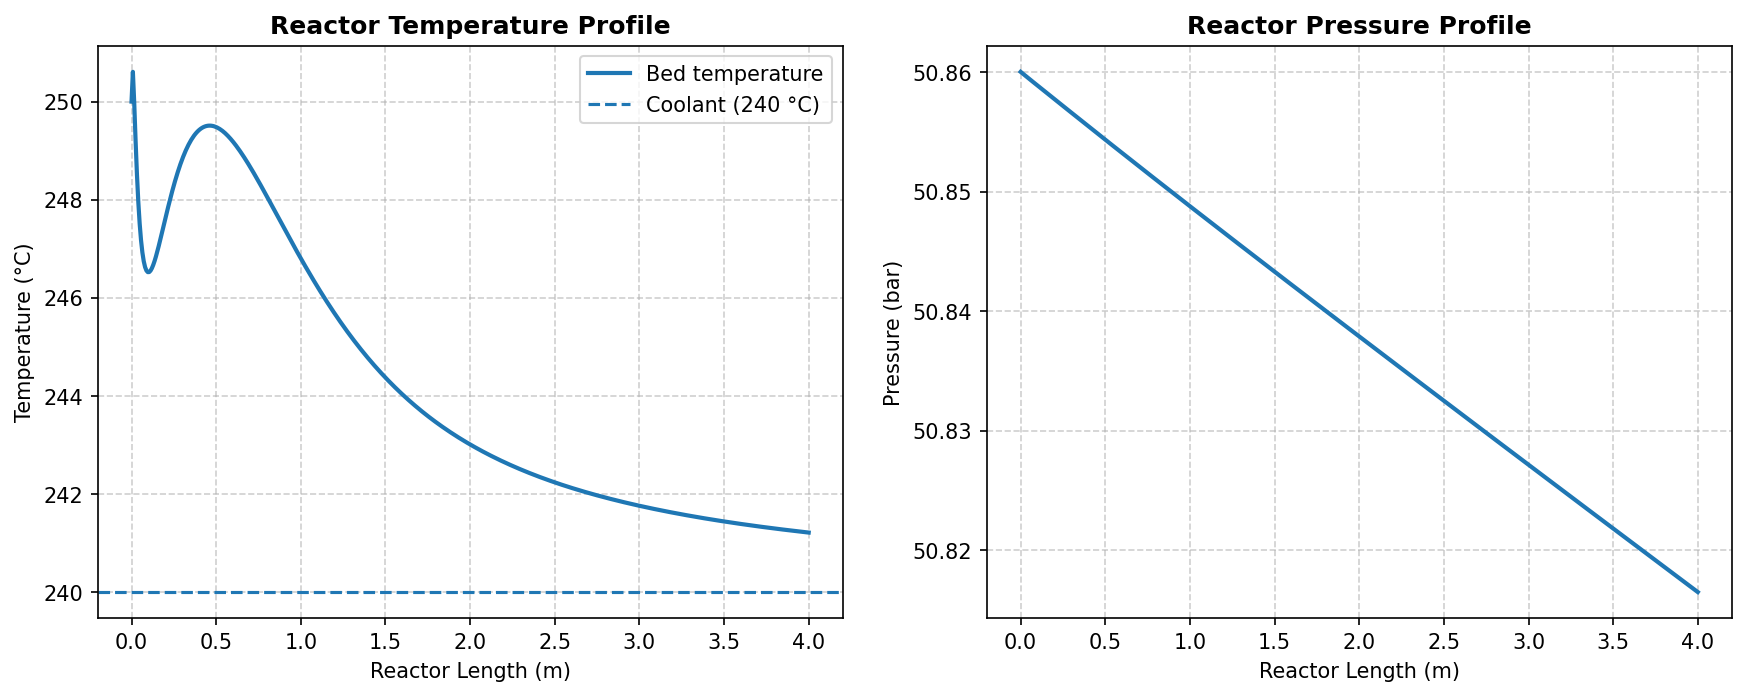

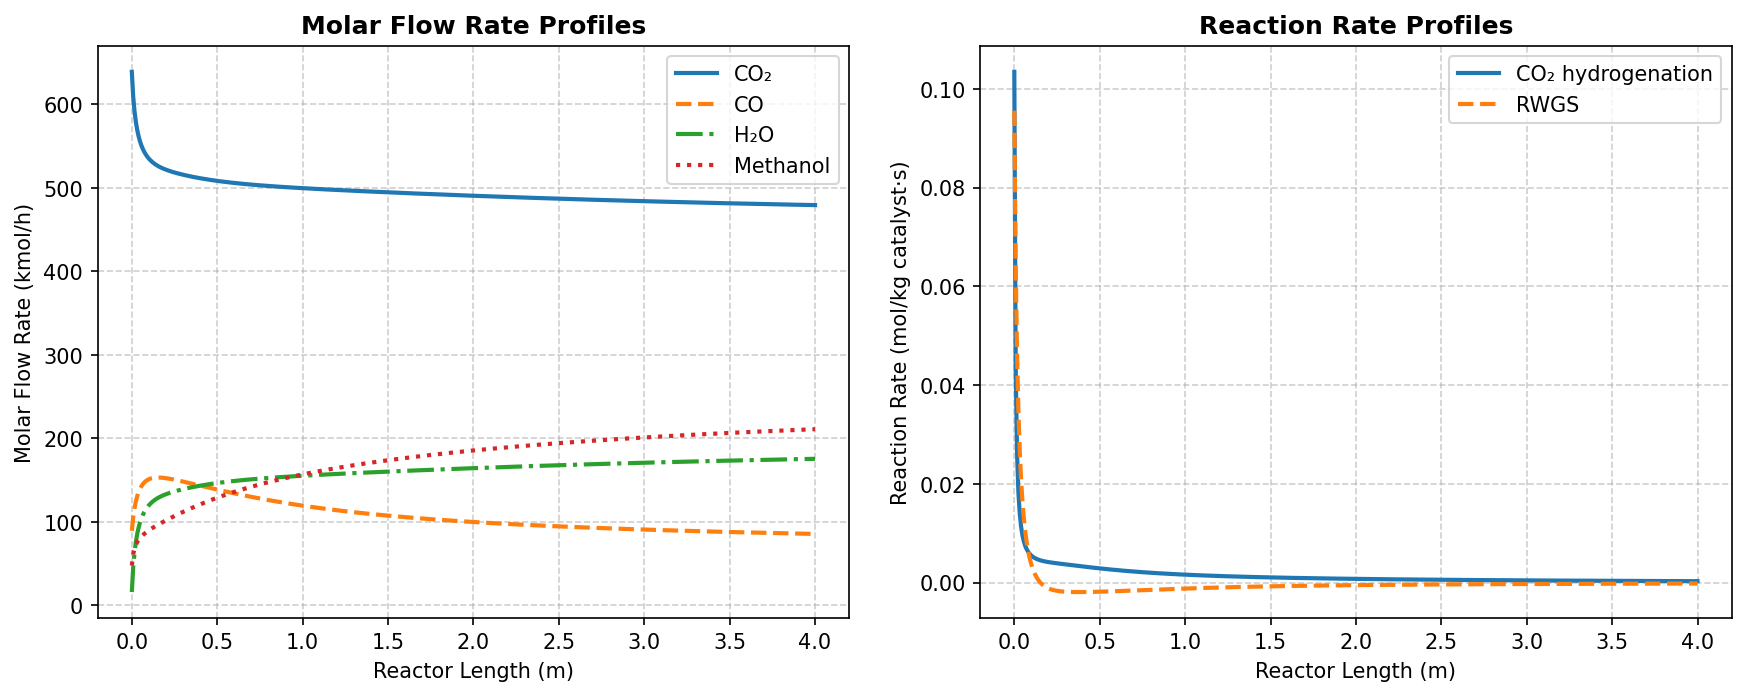

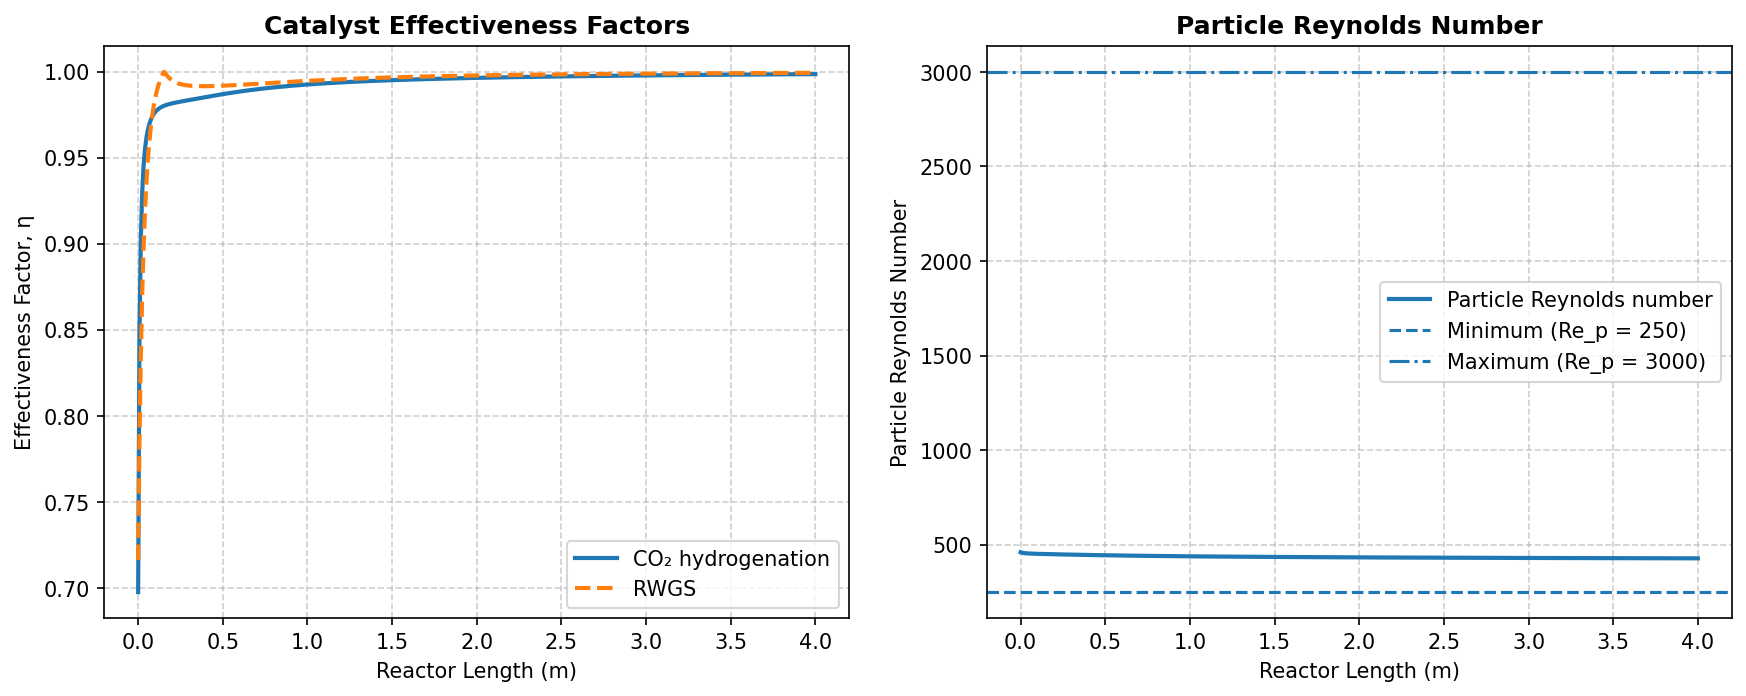

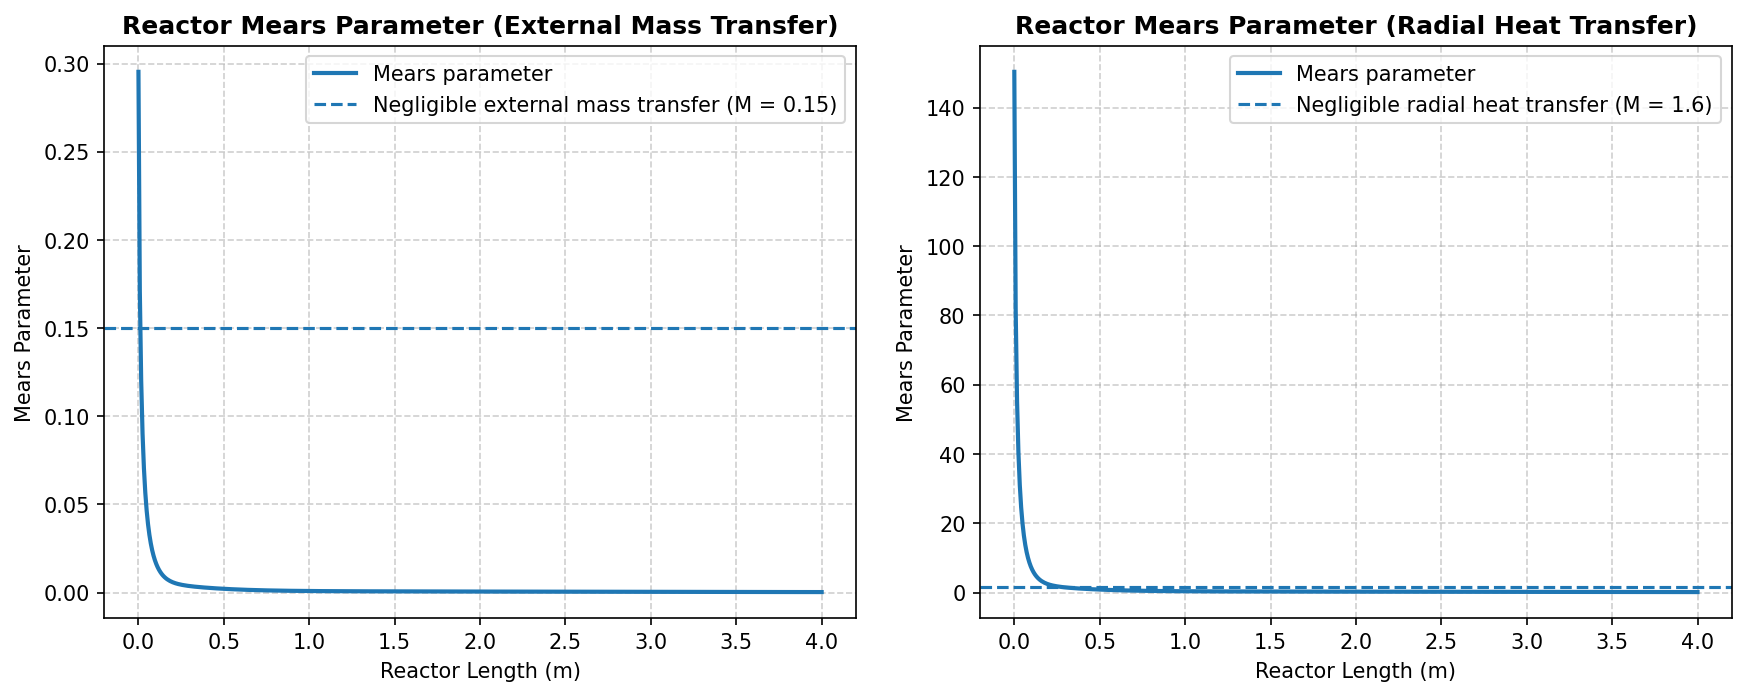

In [4]:
import math

print('-------------------------------------------------------------------------------------')
print('########## PERFORMANCE METRICS ##########')
print('Overall methanol production {:.4g} kg/h'.format(x_meoh_D * D * 3.6 * 32))
print('Overall carbon efficiency {:.4g} %'.format((x_meoh_D * D * 3.6) * 100 / ((y_fresh[0] + y_fresh[1] + y_fresh[2] + y_fresh[5]) * F_fresh)))
print('Overall CO2 conversion (fresh-feed basis) {:.4g} %'.format((y_fresh[2] * F_fresh - y_2[2] * F_2 * 3.6) * 100 / (y_fresh[2] * F_fresh)))
print('Overall H2 conversion (fresh-feed basis) {:.4g} %'.format((y_fresh[4] * F_fresh - y_2[4] * F_2 * 3.6) * 100 / (y_fresh[4] * F_fresh)))
print('Recycle ratio (recycle:fresh feed) {:.4g}'.format(F_recycle1 / F_fresh))
print('Specific compressor power consumption {:.4g} kWh/tonne MeOH'.format((W_co / 1e3) / (x_meoh_D * D * 3.6 * 32 / 1e3)))
print('Specific reboiler thermal duty {:.4g} kWh/tonne MeOH'.format((Q_reb / 1e3) / (x_meoh_D * D * 3.6 * 32 / 1e3)))
print('-------------------------------------------------------------------------------------')
print('########## FRESH SYNGAS ##########')
print('Temperature: {:.4g} °C'.format(T_fresh - 273.15))
print('Pressure: {:.4g} bar'.format(P_fresh / 1e5))
print('Flow rate: {:.4g} kmol/h'.format(F_fresh))
print('Molar fractions: Methane, Carbon monoxide, Carbon dioxide, Water, Hydrogen, Methanol')
print('Molar fractions: ', [f'{x:.4g}' for x in y_fresh])
print('-------------------------------------------------------------------------------------')
print('########## RECYCLE ##########')
print('Temperature: {:.4g} °C'.format(T_recycle - 273.15))
print('Pressure: {:.4g} bar'.format(P_recycle / 1e5))
print('Flow rate: {:.4g} kmol/h'.format(F_recycle))
print('Molar fractions: Methane, Carbon monoxide, Carbon dioxide, Water, Hydrogen, Methanol')
print('Molar fractions: ', [f'{x:.4g}' for x in y_recycle])
print('-------------------------------------------------------------------------------------')
print('########## MIXER ##########')
print('Temperature: {:.4g} °C'.format(T_mix - 273.15))
print('Pressure: {:.4g} bar'.format(P_mix / 1e5))
print('Flow rate: {:.4g} kmol/h'.format(F_mix))
print('Molar fractions: Methane, Carbon monoxide, Carbon dioxide, Water, Hydrogen, Methanol')
print('Molar fractions: ', [f'{x:.4g}' for x in y_mix])
print('-------------------------------------------------------------------------------------')
print('########## PREHEATER ##########')
print('Inlet temperature: {:.4g} °C'.format(T_mix - 273.15))
print('Outlet temperature: {:.4g} °C'.format(T_ph - 273.15))
print('Inlet pressure: {:.4g} bar'.format(P_mix * 1e-5))
print('Pressure drop: {:.4g} bar'.format(P_ph_drop / 1e5))
print('Flow rate: {:.4g} kmol/h'.format(F_mix))
print('Molar fractions: Methane, Carbon monoxide, Carbon dioxide, Water, Hydrogen, Methanol')
print('Molar fractions: ', [f'{x:.4g}' for x in y_mix])
print('Required duty: {:.4g} MW'.format(Q_ph / 1e6))
print('Utility: steam condensation entering at {:.4g} °C and exiting at {:.4g} °C'.format(T_ph_util_in - 273.15, T_ph_util_out - 273.15))
print('Overall heat transfer coefficient: {:.4g} W/m^2K'.format(U_ph))
print('Heat exchanger area: {:.4g} m^2'.format(A_ph))
print('Number of tubes: {:.4g} tubes'.format(math.ceil(N_ph_t)))
print('Tube length: {:.4g} m'.format(L_ph_t))
print('Reynolds number: {:.4g}, Flow regime: {}'.format(Re_ph, regime_ph))
print('Prandtl number: {:.4g}'.format(Pr_ph))
print('Nusselt number: {:.4g}'.format(Nu_ph))
print('Capital cost: ZAR {:.4g} million'.format(Cost_ph / 1e6))
print('Utility cost: ZAR {:.4g} per hour'.format(op_ph))
print('-------------------------------------------------------------------------------------')
print('########## REACTOR ##########')
print('Inlet temperature: {:.4g} °C'.format(T_rfeed - 273.15))
print('Outlet temperature: {:.4g} °C'.format(T_r[-1] - 273.15))
print('Pressure drop: {:.4g} bar'.format((P_rfeed - P_r[-1]) / 1e5))
print('Inlet flow rate: {:.4g} kmol/h'.format(F_mix))
print('Outlet flow rate: {:.4g} kmol/h'.format(F_mix_r[-1] * 3.6))
print('Molar fractions: Methane, Carbon monoxide, Carbon dioxide, Water, Hydrogen, Methanol')
print('Inlet molar fractions: ', [f'{x:.4g}' for x in y_mix])
print('Outlet molar fractions: ', [f'{x:.4g}' for x in y_r_out])
print('Single-pass CO2 conversion {:.4g} %'.format((((y_mix[2] * F_mix) - (y_r_out[2] * F_mix_r[-1] * 3.6)) / (y_mix[2] * F_mix)) * 100))
print('Single-pass MeOH formation {:.4g} kg/h'.format((-(y_mix[5] * F_mix) + (y_r_out[5] * F_mix_r[-1] * 3.6)) * 32))
print('Tube length: {:.4g} m'.format(L_t))
print('Number of tubes: {:.4g} tubes'.format(math.ceil(N_t)))
print('Particle size: {:.4g} mm, Cu/ZnO/Al2O3, cylindrical'.format(d_p * 1e3))
print('Packing density: {:.4g} kg/m^3'.format(bed_density))
print('Catalyst mass: {:.4g} tonnes'.format(N_t * A_r_c * L_t * bed_density / 1e3))
print('Cooling duty removed by reactor jacket: {:.4g} MW'.format(Q_reactor / 1e6))
print('Cooling utility temperature: {:.4g} °C'.format(Temp_util_in - 273.15))
print('Hotspot peak temperature: {:.4g} °C at L = {:.4g} m'.format(T_hotspot, L_hotspot))
print('Peclet number: {:.4g}, Regime: {}'.format(Pe_r, Pe_regime))
print('Particle Reynolds number: {:.4g} (minimum), {:.4g} (maximum), Criterion: 250 < Re_p < 3000, {}'.format(min(reynolds), max(reynolds), 'Satisfied' if (reynolds_min_ok and reynolds_max_ok) else 'Not satisfied'))
print('Mears criterion (external mass transfer): {:.4g}, Criterion: < 0.15, {}'.format(max(mears_ext), 'Satisfied' if mears_ext_ok else 'Not satisfied'))
print('Mears criterion (radial heat transfer): {:.4g}, Criterion: < 1.6, {}'.format(max(mears_rad), 'Satisfied' if mears_radial_ok else 'Not satisfied'))
print('Capital cost: ZAR {:.4g} million'.format(Cost_r / 1e6))
print('Catalyst cost: ZAR {:.4g} million'.format(Cost_cat / 1e6))
print('Utility cost: ZAR {:.4g} per hour'.format(op_r))
print('-------------------------------------------------------------------------------------')
print('########## COOLER ##########')
print('Inlet temperature: {:.4g} °C'.format(T_r_out - 273.15))
print('Outlet temperature: {:.4g} °C'.format(T_c - 273.15))
print('Inlet pressure: {:.4g} bar'.format(P_r_out * 1e-5))
print('Pressure drop: {:.4g} bar'.format(P_c_drop / 1e5))
print('Flow rate: {:.4g} kmol/h'.format(F_mix_r[-1] * 3.6))
print('Molar fractions: Methane, Carbon monoxide, Carbon dioxide, Water, Hydrogen, Methanol')
print('Molar fractions: ', [f'{x:.4g}' for x in y_r_out])
print('Required duty: {:.4g} MW'.format(Q_c / 1e6))
print('Utility: cooling water entering at {:.4g} °C and exiting at {:.4g} °C'.format(T_c_util_in - 273.15, T_c_util_out - 273.15))
print('Overall heat transfer coefficient: {:.4g} W/m^2K'.format(U_c))
print('Heat exchanger area: {:.4g} m^2'.format(A_c))
print('Number of tubes: {:.4g} tubes'.format(math.ceil(N_c_t)))
print('Tube length: {:.4g} m'.format(L_c_t))
print('Reynolds number: {:.4g}, Flow regime: {}'.format(Re_c, regime_c))
print('Prandtl number: {:.4g}'.format(Pr_c))
print('Nusselt number: {:.4g}'.format(Nu_c))
print('Capital cost: ZAR {:.4g} million'.format(Cost_c / 1e6))
print('Utility cost: ZAR {:.4g} per hour'.format(op_c))
print('-------------------------------------------------------------------------------------')
print('########## FLASH DRUM ##########')
print('Temperature: {:.4g} °C'.format(T_flash - 273.15))
print('Pressure: {:.4g} bar'.format(P_flash / 1e5))
print('Flow rate: {:.4g} kmol/h'.format(F_flash * 3.6))
print('Molar fractions: Methane, Carbon monoxide, Carbon dioxide, Water, Hydrogen, Methanol')
print('Molar fractions: ', [f'{x:.4g}' for x in y_r_out])
print('Vapour molar fractions: ', [f'{x:.4g}' for x in y_vap])
print('Liquid molar fractions: ', [f'{x:.4g}' for x in y_liq])
print('Vapour fraction: {:.4g} %'.format(VF_flash * 100))
print('Capital cost: ZAR {:.4g} million'.format(Cost_fd / 1e6))
print('Drum height: {:.4g} m'.format(h_fd))
print('Liquid height: {:.4g} m'.format(h_l_fd))
print('Vapour clearance height: {:.4g} m'.format(h_v_fd))
print('Drum diameter: {:.4g} m'.format(D_fd))
print('Drum volume: {:.4g} m^3'.format(V_fd))
print('-------------------------------------------------------------------------------------')
print('########## SPLITTER ##########')
print('Split ratio (recycle-to-purge): {:.4g}'.format(split))
print('-------------------------------------------------------------------------------------')
print('########## PURGE ##########')
print('Temperature: {:.4g} °C'.format(T_2 - 273.15))
print('Pressure: {:.4g} bar'.format(P_2 / 1e5))
print('Flow rate: {:.4g} kmol/h'.format(F_2 * 3.6))
print('Molar fractions: Methane, Carbon monoxide, Carbon dioxide, Water, Hydrogen, Methanol')
print('Molar fractions: ', [f'{x:.4g}' for x in y_2])
print('-------------------------------------------------------------------------------------')
print('########## COMPRESSOR ##########')
print('Inlet temperature: {:.4g} °C'.format(T_1 - 273.15))
print('Outlet temperature: {:.4g} °C'.format(T_recycle1 - 273.15))
print('Inlet pressure: {:.4g} bar'.format(P_1 / 1e5))
print('Outlet pressure: {:.4g} bar'.format(P_recycle / 1e5))
print('Flow rate: {:.4g} kmol/h'.format(F_1 * 3.6))
print('Electrical power duty: {:.4g} kW'.format(W_co/1e3))
print('Molar fractions: Methane, Carbon monoxide, Carbon dioxide, Water, Hydrogen, Methanol')
print('Molar fractions: ', [f'{x:.4g}' for x in y_1])
print('Isentropic efficiency: {:.4g} %'.format(isen_efficiency * 100))
print('Capital cost: ZAR {:.4g} million'.format(Cost_co / 1e6))
print('Utility cost: ZAR {:.4g} per hour'.format(op_co))
print('-------------------------------------------------------------------------------------')
print('########## THROTTLING VALVE ##########')
print('Inlet temperature: {:.4g} °C'.format(T_flash - 273.15))
print('Outlet temperature: {:.4g} °C'.format(T_valve - 273.15))
print('Inlet pressure: {:.4g} bar'.format(P_flash / 1e5))
print('Outlet pressure: {:.4g} bar'.format(P_valve / 1e5))
print('Flow rate: {:.4g} kmol/h'.format(F_valve * 3.6))
print('Molar fractions: Methane, Carbon monoxide, Carbon dioxide, Water, Hydrogen, Methanol')
print('Molar fractions: ', [f'{x:.4g}' for x in y_liq])
print('Vapour fraction: {:.4g} %'.format(valve.VF * 100))
print('-------------------------------------------------------------------------------------')
print('########## DISTILLATION COLUMN ##########')
print('Feed temperature: {:.4g} °C'.format(T_valve - 273.15))
print('Feed pressure: {:.4g} bar'.format(P_valve / 1e5))
print('Feed flow rate: {:.4g} kmol/h'.format(Feed * 3.6))
print('Feed molar fractions: {:.4g} MeOH, {:.4g} H2O'.format(z_meoh, z_h2o))
print('Feed quality {:.4g}'.format(q))
print('Distillate temperature: {:.4g} °C'.format(top[0] - 273.15))
print('Distillate pressure: {:.4g} bar'.format(5))
print('Distillate flow rate: {:.4g} kmol/h'.format(D * 3.6))
print('Distillate molar fractions: {:.4g} MeOH, {:.4g} H2O'.format(x_meoh_D, (1 - x_meoh_D)))
print('Bottoms temperature: {:.4g} °C'.format(bot[0] - 273.15))
print('Bottoms pressure: {:.4g} bar'.format(5))
print('Bottoms flow rate: {:.4g} kmol/h'.format(B * 3.6))
print('Bottoms molar fractions: {:.4g} MeOH, {:.4g} H2O'.format((1 - x_h2o_B), x_h2o_B))
print('Minimum number of stages {:.4g} stages'.format(N_min))
print('Actual number of stages {:.4g} stages'.format(math.ceil(N_actual)))
print('Minimum molar reflux ratio {:.4g}'.format(R_min))
print('Actual molar reflux ratio {:.4g}'.format(R_actual))
print('Condenser duty (total condenser): {:.4g} kW'.format(Q_con / 1e3))
print('Reboiler duty (partial reboiler): {:.4g} kW'.format(Q_reb / 1e3))
print('Capital cost: ZAR {:.4g} million'.format((Cost_tc + Cost_rb + Cost_trays + Cost_col) / 1e6))
print('Top-condenser utility cost: ZAR {:.4g} per hour'.format(op_tc))
print('Bottom-reboiler utility cost: ZAR {:.4g} per hour'.format(op_rb))
print('Tray efficiency: {:.4g} %'.format(tray_efficiency * 100))
print('Number of trays: {:.4g} trays'.format(math.ceil(N_trays)))
print('Height: {:.4g} m'.format(h_col))
print('Diameter: {:.4g} m'.format(D_col))
print('-------------------------------------------------------------------------------------')
print('########## TOTAL ANNUALISED COST ##########')
print('Total capital cost: ZAR {:.4g} million'.format(tot_cap / 1e6))
print('Discount rate: {:.4g} %'.format(r_disc * 100))
print('Plant lifetime: {:.4g} years'.format(n_life))
print('Annual operating hours: {:.4g} hours'.format(op_hours))
print('Total annual operating costs: ZAR {:.4g} million'.format(tot_op * op_hours / 1e6))
print('Total annualised cost: ZAR {:.4g} million'.format(TAC / 1e6))

import os
import matplotlib.pyplot as plt

output_dir = r"C:\Users\trist\Desktop\4th Year\Semester2\CPJ 421\Reactor_profiles"
os.makedirs(output_dir, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

axes[0].plot(L_t_span, T_r - 273.15, linewidth=2, linestyle='-', label='Bed temperature')
axes[0].axhline(
    Temp_util_in - 273.15,
    linestyle='--',
    linewidth=1.5,
    label=f'Coolant ({Temp_util_in - 273.15:.0f} °C)'
)
axes[0].set_title('Reactor Temperature Profile', fontweight='bold')
axes[0].set_xlabel('Reactor Length (m)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

axes[1].plot(L_t_span, P_r / 1e5, linewidth=2, linestyle='-')
axes[1].set_title('Reactor Pressure Profile', fontweight='bold')
axes[1].set_xlabel('Reactor Length (m)')
axes[1].set_ylabel('Pressure (bar)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(output_dir, 'temperature_and_pressure.svg'), format='svg', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

axes[0].plot(L_t_span, FC_r * 3.6, linewidth=2, linestyle='-', label='CO₂')
axes[0].plot(L_t_span, FB_r * 3.6, linewidth=2, linestyle='--', label='CO')
axes[0].plot(L_t_span, FD_r * 3.6, linewidth=2, linestyle='-.', label='H₂O')
axes[0].plot(L_t_span, FF_r * 3.6, linewidth=2, linestyle=':', label='Methanol')
axes[0].set_title('Molar Flow Rate Profiles', fontweight='bold')
axes[0].set_xlabel('Reactor Length (m)')
axes[0].set_ylabel('Molar Flow Rate (kmol/h)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

axes[1].plot(L_t_span, r1, linewidth=2, linestyle='-', label='CO₂ hydrogenation')
axes[1].plot(L_t_span, r2, linewidth=2, linestyle='--', label='RWGS')
axes[1].set_title('Reaction Rate Profiles', fontweight='bold')
axes[1].set_xlabel('Reactor Length (m)')
axes[1].set_ylabel('Reaction Rate (mol/kg catalyst·s)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(output_dir, 'molar_flows_and_reaction_rates.svg'), format='svg', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

axes[0].plot(L_t_span, eta_1, linewidth=2, linestyle='-', label='CO₂ hydrogenation')
axes[0].plot(L_t_span, eta_2, linewidth=2, linestyle='--', label='RWGS')
axes[0].set_title('Catalyst Effectiveness Factors', fontweight='bold')
axes[0].set_xlabel('Reactor Length (m)')
axes[0].set_ylabel('Effectiveness Factor, η')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

axes[1].plot(L_t_span, Re_p_r, linewidth=2, linestyle='-', label='Particle Reynolds number')
axes[1].axhline(250, linestyle='--', linewidth=1.5, label='Minimum (Re_p = 250)')
axes[1].axhline(3000, linestyle='-.', linewidth=1.5, label='Maximum (Re_p = 3000)')
axes[1].set_title('Particle Reynolds Number', fontweight='bold')
axes[1].set_xlabel('Reactor Length (m)')
axes[1].set_ylabel('Particle Reynolds Number')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(output_dir, 'eta_and_reynolds.svg'), format='svg', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

axes[0].plot(L_t_span, CM_r, linewidth=2, linestyle='-', label='Mears parameter')
axes[0].axhline(
    0.15,
    linestyle='--',
    linewidth=1.5,
    label='Negligible external mass transfer (M = 0.15)'
)
axes[0].set_title('Reactor Mears Parameter (External Mass Transfer)', fontweight='bold')
axes[0].set_xlabel('Reactor Length (m)')
axes[0].set_ylabel('Mears Parameter')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

axes[1].plot(L_t_span, M_T, linewidth=2, linestyle='-', label='Mears parameter')
axes[1].axhline(
    1.6,
    linestyle='--',
    linewidth=1.5,
    label='Negligible radial heat transfer (M = 1.6)'
)
axes[1].set_title('Reactor Mears Parameter (Radial Heat Transfer)', fontweight='bold')
axes[1].set_xlabel('Reactor Length (m)')
axes[1].set_ylabel('Mears Parameter')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(output_dir, 'mears_parameters.svg'), format='svg', bbox_inches='tight')
plt.show()